<a href="https://colab.research.google.com/github/lucyZihanZ/Optimization_in_Data_Science/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd
import itertools

# Optimization algorithms

## Stochastic Cubic Regularized Method

In [ ]:
def hessian_vector_product(f, x, v):
    grad = torch.autograd.grad(f(x), x, create_graph=True)[0]
    hvp = torch.autograd.grad(grad @ v, x, retain_graph=True)[0]
    return hvp


# Cubic-Subsolver (Algorithm 2)
def cubic_subsolver(g, hessian_vector_product, epsilon, rho, l, c_prime=1.0, max_iters=100):
    g_norm = torch.norm(g) + 1e-10  # Avoid zero norm
    if g_norm >= (l ** 2) / rho:
        Rc_num = g @ hessian_vector_product(g)
        Rc_denom = rho * g_norm**2 + 1e-10  # Avoid division by zero
        Rc = (-Rc_num / Rc_denom
              + torch.sqrt((Rc_num / Rc_denom)**2 + (2 * g_norm / rho)))
        delta = -Rc * (g / g_norm)
    else:
        delta = torch.zeros_like(g, requires_grad=True)
        sigma = c_prime * torch.sqrt(torch.tensor(epsilon * rho)) / l
        eta = 1 / (20 * l)
        zeta = torch.randn_like(g)
        zeta = zeta.div(torch.norm(zeta) + 1e-10)
        g_tilde = g + sigma * zeta
        for _ in range(max_iters):
            grad_step = g_tilde + hessian_vector_product(delta) + (rho / 2) * torch.norm(delta) * delta
            delta = delta - eta * grad_step
            if torch.norm(grad_step) < epsilon:
                break
    # Compute delta_m
    hvp_delta = hessian_vector_product(delta)
    delta_m = g @ delta + 0.5 * delta @ hvp_delta + (rho / 6) * torch.norm(delta)**3
    return delta.detach(), delta_m


# Cubic-Finalsolver (Algorithm 3)
def cubic_finalsolver(g, hessian_vector_product, epsilon, l, rho):
    delta = torch.zeros_like(g, requires_grad=True)
    g_m = g.clone()
    eta = 1 / (20 * l)
    while torch.norm(g_m) > epsilon / 2:
        delta = delta - eta * g_m
        g_m = g + hessian_vector_product(delta) + (rho / 2) * torch.norm(delta) * delta
    return delta.detach()

# Stochastic Cubic Regularization (SCR) - Algorithm 1
def stochastic_cubic_regularization(x0, f, num_iterations, epsilon, rho, l, n1, n2, X, Y):
    def sample_minibatch(X, Y, batch_size):
        indices = torch.randperm(X.size(0))[:batch_size]
        return X[indices], Y[indices]

    x = x0.clone().detach().requires_grad_(True)
    c = -(epsilon ** 3 / rho) ** (0.5) / 100  # Early stopping threshold

    for _ in range(num_iterations):
        # Sample mini-batches
        X1, Y1 = sample_minibatch(X, Y, n1)  # For gradient
        X2, Y2 = sample_minibatch(X, Y, n2)  # For Hessian

        f_S1 = lambda x: torch.mean(torch.stack([f(x, X1[i], Y1[i]) for i in range(X1.size(0))]))
        grad = torch.autograd.grad(f_S1(x), x, create_graph=True)[0]

        def hessian_vector(v):
            f_S2 = lambda x: torch.mean(torch.stack([f(x, X2[i], Y2[i]) for i in range(X2.size(0))]))
            return hessian_vector_product(f_S2, x, v)

        delta, delta_m = cubic_subsolver(grad, hessian_vector, epsilon, rho, l)
        x_new = (x + delta).detach().requires_grad_(True)

        if delta_m >= c:
            delta_final = cubic_finalsolver(grad, hessian_vector, epsilon, l, rho)
            return x + delta_final

        x = x_new

    return x


## Adagrad Method

In [ ]:
# Adaptive Gradient Method -Algorithm 1
def adagrad_mse(grad_func, x_init, targets, stepsize, num_iterations):
    x = x_init.clone().detach()
    G = torch.zeros_like(x)
    loss_history = []
    for t in range(1, num_iterations + 1):
        predictions = grad_func(x)
        loss = mse_loss(predictions, targets)
        loss_history.append(loss.item())

        # compute the gradient for x optimization
        grad = grad_func(x) - targets
        G += grad ** 2
        adjusted_gradient = grad / (torch.sqrt(G) + 1e-8)
        x -= stepsize * adjusted_gradient
    return x, loss_history

# Adaptive Gradient Method - AdaDelta method, taking an exponential weighted average Algorithms 2
def adagrad(grad_func, x_init, stepsize, num_iterations, batch_size,rho, tol):
  # initial parameters x: start point and G: initial gradient
    x = x_init.clone().detach()
    G = torch.zeros_like(x)
    loss_set = []
    for t in range(1, num_iterations + 1, batch_size):
        # print(f"It's the {t} times iteration")
        grad = grad_func(x)
        G = rho * G + (1 - rho) * grad * grad # exponential weighted average
        G_inv_sqrt = torch.diag(1.0 / (torch.sqrt(G) + 1e-8))
        x_new = x - stepsize * G_inv_sqrt @ grad
        loss = mse_loss(x_new)
        loss_set.append(loss)
        if torch.all(torch.abs(x_new - x) <= 0.001):
            print("Convergence achieved")
        print(f"the loss is {loss}")
        print(f"the x value is{x}")
        x = x_new

    return x, loss_set

## SGD Method

In [ ]:
#SGD benchmark model
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(1, 1)  # Example: 1 input, 1 output

    def forward(self, x):
        return self.fc(x)

model = SimpleModel()

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

for epoch in range(100):  # Number of epochs
    # Example input and target
    inputs = torch.tensor([[1.0], [2.0], [3.0]])
    targets = torch.tensor([[2.0], [4.0], [6.0]])

    # Forward pass
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    # Backward pass and optimization
    optimizer.zero_grad()  # Clear previous gradients
    loss.backward()        # Compute gradients
    optimizer.step()       # Update weights

    print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')
torch.save(model.state_dict(), 'model.pth')
model.load_state_dict(torch.load('model.pth'))
model.eval()  # Switch to evaluation mode


def plot_loss(loss_set, optimizer_name="SGD"):
    """
    Generate a plot for the loss function over training time.

    Parameters:
    - loss_set (list or array): A sequence of loss values collected during training.
    - optimizer_name (str): The name of the optimizer used, default is "SGD".

    Returns:
    None
    """
    plt.plot(loss_set)
    plt.title(f"Loss Function for {SGD}")
    plt.xlabel("Training Time")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

Epoch [1/100], Loss: 12.5335
Epoch [2/100], Loss: 9.9327
Epoch [3/100], Loss: 6.0414
Epoch [4/100], Loss: 2.4738
Epoch [5/100], Loss: 0.4270
Epoch [6/100], Loss: 0.2681
Epoch [7/100], Loss: 1.5400
Epoch [8/100], Loss: 3.3028
Epoch [9/100], Loss: 4.6091
Epoch [10/100], Loss: 4.8912
Epoch [11/100], Loss: 4.1203
Epoch [12/100], Loss: 2.7146
Epoch [13/100], Loss: 1.2821
Epoch [14/100], Loss: 0.3349
Epoch [15/100], Loss: 0.0970
Epoch [16/100], Loss: 0.4666
Epoch [17/100], Loss: 1.1188
Epoch [18/100], Loss: 1.6806
Epoch [19/100], Loss: 1.8920
Epoch [20/100], Loss: 1.6902
Epoch [21/100], Loss: 1.1979
Epoch [22/100], Loss: 0.6368
Epoch [23/100], Loss: 0.2183
Epoch [24/100], Loss: 0.0581
Epoch [25/100], Loss: 0.1471
Epoch [26/100], Loss: 0.3784
Epoch [27/100], Loss: 0.6094
Epoch [28/100], Loss: 0.7267
Epoch [29/100], Loss: 0.6870
Epoch [30/100], Loss: 0.5207
Epoch [31/100], Loss: 0.3062
Epoch [32/100], Loss: 0.1278
Epoch [33/100], Loss: 0.0402
Epoch [34/100], Loss: 0.0518
Epoch [35/100], Loss: 

<ipython-input-5-b2e6f811874d>:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('model.pth'))


# Experiment
Synthetic non-convex rosenbrock function

--------------------------------------------
Starting SCR optimization:
Iteration: 1, Loss: 0.15692037343978882
Iteration: 2, Loss: 0.11848866194486618
Iteration: 3, Loss: 0.10588156431913376
Iteration: 4, Loss: 0.07515495270490646
Iteration: 5, Loss: 0.06899257749319077
Iteration: 6, Loss: 0.05747396871447563
Iteration: 7, Loss: 0.05326938256621361
Iteration: 8, Loss: 0.028456371277570724
Iteration: 9, Loss: 0.02659137360751629
Iteration: 10, Loss: 0.02333807200193405
Iteration: 11, Loss: 0.0220638420432806
Iteration: 12, Loss: 0.013284706510603428
Iteration: 13, Loss: 0.012468976899981499
Iteration: 14, Loss: 0.01158221997320652
Iteration: 15, Loss: 0.010943987406790257
Iteration: 16, Loss: 0.009834188967943192
Iteration: 17, Loss: 0.009374711662530899
Iteration: 18, Loss: 0.014850754290819168
Iteration: 19, Loss: 0.013580089434981346
Iteration: 20, Loss: 0.012912783771753311
--------------------------------------------
Starting AdaGrad optimization:
Iteration: 2, Loss: 4.25
Iteratio

<ipython-input-6-8f0e9d6f474d>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, requires_grad=True)


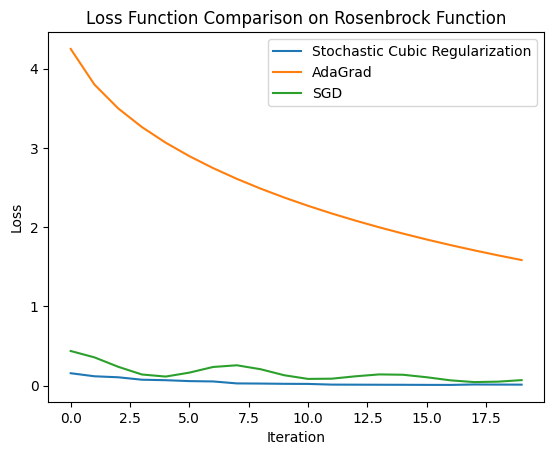

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define a non-convex function
def rosenbrock(x, y):
    return (1 - x)**2 + 3 * (y - x**2)**2

def grad_rosenbrock(x):
    x = torch.tensor(x, requires_grad=True)
    f = rosenbrock(x[0], x[1])
    f.backward()

    grad_x = x.grad[0].item()
    grad_y = x.grad[1].item()

    return torch.tensor([grad_x, grad_y])

def mse_loss(actual, predicted):
    return torch.mean((predicted - actual) ** 2)

# Parameters
x_init = torch.tensor([0.5, 0.5], requires_grad=True) # values close to optimal values works well
epsilon = 1e-2
rho = 10.0
l = 1.0
stepsize = 0.01
num_iterations = 20
n1, n2 = 5, 5
X = torch.rand(100, 1)  # Dummy dataset
Y = torch.rand(100, 1)

print("--------------------------------------------")
print("Starting SCR optimization:")
# SCR experiment
loss_set_scr = []
x_scr = x_init.clone().detach().requires_grad_(True)
for i in range(num_iterations):
    x_scr = stochastic_cubic_regularization(x_scr, lambda x, xi, yi: rosenbrock(x[0], x[1]),
                                            num_iterations=1, epsilon=epsilon, rho=rho, l=l,
                                            n1=n1, n2=n2, X=X, Y=Y)
    loss = rosenbrock(x_scr[0], x_scr[1]).item()
    loss_set_scr.append(loss)
    print(f"Iteration: {i + 1}, Loss: {loss}")
print("--------------------------------------------")
print("Starting AdaGrad optimization:")
# AdaGrad experiment
x = x_init.clone().detach()
G = torch.zeros_like(x)
loss_history = []
targets = torch.tensor([0.,0.])
for i in range(1, num_iterations + 1):
    predictions = grad_rosenbrock(x)
    loss = mse_loss(predictions, targets)
    loss_history.append(loss.item())
    grad = grad_rosenbrock(x) - targets
    G += grad ** 2
    adjusted_gradient = grad / (torch.sqrt(G) + 1e-8)
    x -= stepsize * adjusted_gradient
    print(f"Iteration: {i + 1}, Loss: {loss}")
print("--------------------------------------------")
print("Starting SGD optimization:")
# SGD experiment
loss_set_sgd = []
x_sgd = x_init.clone().detach().requires_grad_(True)
optimizer = optim.SGD([x_sgd], lr=stepsize, momentum=0.9)
criterion = nn.MSELoss()

for i in range(num_iterations):
    optimizer.zero_grad()  # Clear gradients
    loss = rosenbrock(x_sgd[0], x_sgd[1])
    loss.backward()        # Compute gradients with respect to x_sgd
    optimizer.step()       # Update x_sgd

    loss_set_sgd.append(loss.item())
    print(f"Iteration: {i + 1}, Loss: {loss.item()}")

# Plotting Loss Comparison
plt.plot(loss_set_scr, label="Stochastic Cubic Regularization")
plt.plot(loss_history, label="AdaGrad")
plt.plot(loss_set_sgd, label="SGD")
plt.title("Loss Function Comparison on Rosenbrock Function")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Sensitivity Analysis

In [ ]:

epsilon_values = [1e-2, 1e-3]  # Convergence thresholds
rho_values = [1.0, 10.0]  # For SCR
stepsize_values = [0.01, 0.1]  # For AdaGrad and SGD
momentum_values = [0.0, 0.9]  # For SGD
max_iterations = 50  # Fixed
x_init = torch.tensor([0.5, 0.5], requires_grad=True)
n1,n2 = 5,5
X = torch.rand(100, 1)  # Dummy dataset
Y = torch.rand(100, 1)

# Results storage
results = []

# Grid search for all algorithms
for epsilon, rho, stepsize, momentum in itertools.product(epsilon_values, rho_values, stepsize_values, momentum_values):
    print(f"Testing with epsilon={epsilon}, rho={rho}, stepsize={stepsize}, momentum={momentum}, n1={n1}, n2={n2}")

    # SCR Experiment
    x_scr = torch.tensor([0.5, 0.5], requires_grad=True)
    scr_iterations = 0
    while scr_iterations < max_iterations:
        x_scr = stochastic_cubic_regularization(
            x_scr,
            lambda x, xi, yi: rosenbrock(x[0], x[1]),
            num_iterations=1,
            epsilon=epsilon,
            rho=rho,
            l=l,
            n1=n1,
            n2=n2,
            X=X,
            Y=Y
        )
        loss = rosenbrock(x_scr[0], x_scr[1]).item()
        scr_iterations += 1
        if loss < epsilon:
            break
    scr_converged = loss < epsilon

    # AdaGrad Experiment
    x = x_init.clone().detach()
    G = torch.zeros_like(x)
    targets = torch.tensor([0.,0.])
    adagrad_iterations = 0
    while adagrad_iterations < max_iterations:
        predictions = grad_rosenbrock(x)
        loss = mse_loss(predictions, torch.tensor([0., 0.]))
        adagrad_iterations += 1
        grad = grad_rosenbrock(x) - torch.tensor([0., 0.])
        G += grad ** 2
        adjusted_gradient = grad / (torch.sqrt(G) + 1e-8)
        x -= stepsize * adjusted_gradient
        if loss < epsilon:
            break
    adagrad_converged = loss < epsilon

    # SGD Experiment
    x_sgd = torch.tensor([0.5, 0.5], requires_grad=True)
    optimizer = optim.SGD([x_sgd], lr=stepsize, momentum=momentum)
    sgd_iterations = 0
    while sgd_iterations < max_iterations:
        optimizer.zero_grad()  # Clear gradients
        loss = rosenbrock(x_sgd[0], x_sgd[1])
        loss.backward()
        optimizer.step()
        sgd_iterations += 1
        if loss.item() < epsilon:
            break
    sgd_converged = loss.item() < epsilon

    # Store results
    results.append({
        "epsilon": epsilon,
        "rho": rho,
        "stepsize": stepsize,
        "momentum": momentum,
        "SCR_iterations": scr_iterations if scr_converged else max_iterations,
        "AdaGrad_iterations": adagrad_iterations if adagrad_converged else max_iterations,
        "SGD_iterations": sgd_iterations if sgd_converged else max_iterations,
    })

# Convert results to DataFrame
df = pd.DataFrame(results)

# Save results
df.to_csv("sensitivity_analysis_results.csv", index=False)
print(df)

Testing with epsilon=0.01, rho=1.0, stepsize=0.01, momentum=0.0, n1=5, n2=5


<ipython-input-6-8f0e9d6f474d>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, requires_grad=True)


Testing with epsilon=0.01, rho=1.0, stepsize=0.01, momentum=0.9, n1=5, n2=5
Testing with epsilon=0.01, rho=1.0, stepsize=0.1, momentum=0.0, n1=5, n2=5
Testing with epsilon=0.01, rho=1.0, stepsize=0.1, momentum=0.9, n1=5, n2=5
Testing with epsilon=0.01, rho=10.0, stepsize=0.01, momentum=0.0, n1=5, n2=5
Testing with epsilon=0.01, rho=10.0, stepsize=0.01, momentum=0.9, n1=5, n2=5
Testing with epsilon=0.01, rho=10.0, stepsize=0.1, momentum=0.0, n1=5, n2=5
Testing with epsilon=0.01, rho=10.0, stepsize=0.1, momentum=0.9, n1=5, n2=5
Testing with epsilon=0.001, rho=1.0, stepsize=0.01, momentum=0.0, n1=5, n2=5
Testing with epsilon=0.001, rho=1.0, stepsize=0.01, momentum=0.9, n1=5, n2=5
Testing with epsilon=0.001, rho=1.0, stepsize=0.1, momentum=0.0, n1=5, n2=5
Testing with epsilon=0.001, rho=1.0, stepsize=0.1, momentum=0.9, n1=5, n2=5
Testing with epsilon=0.001, rho=10.0, stepsize=0.01, momentum=0.0, n1=5, n2=5
Testing with epsilon=0.001, rho=10.0, stepsize=0.01, momentum=0.9, n1=5, n2=5
Testin

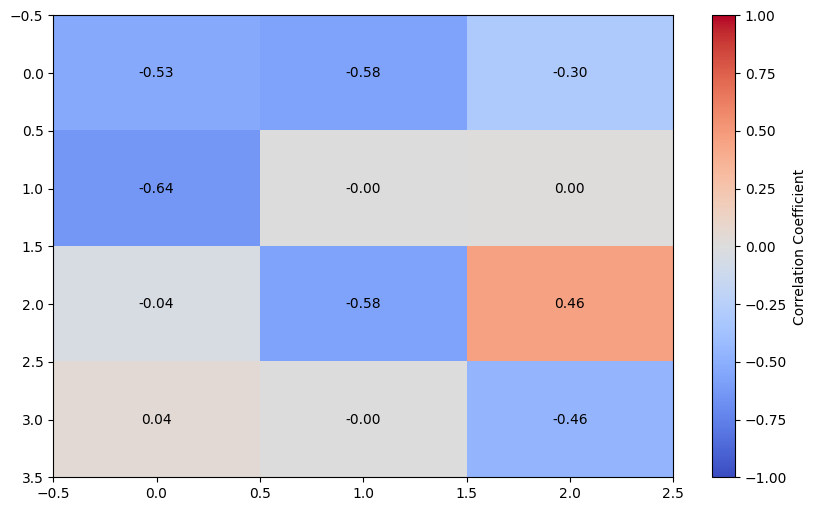

In [ ]:
correlations = df.corr()

# Extract relevant correlations for iteration variables
iteration_vars = ["SCR_iterations", "AdaGrad_iterations", "SGD_iterations"]
correlation_with_iterations = correlations.loc[["epsilon", "rho", "stepsize", "momentum"], iteration_vars]

# Plot the heatmap with numbers
plt.figure(figsize=(10, 6))
plt.imshow(correlation_with_iterations, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label="Correlation Coefficient")

# Adding the correlation values as text
for i in range(correlation_with_iterations.shape[0]):
    for j in range(correlation_with_iterations.shape[1]):
        plt.text(j, i, f"{correlation_with_iterations.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

# Formatting the plot
plt.xticks(range(len(iteration_vars)), iteration_vars, rotation=45, ha="right")
plt.yticks(range(len(correlation_with_iterations.index)), correlation_with_iterations.index)
plt.title("Correlation between Hyperparameters and Iterations with Values")
plt.show()

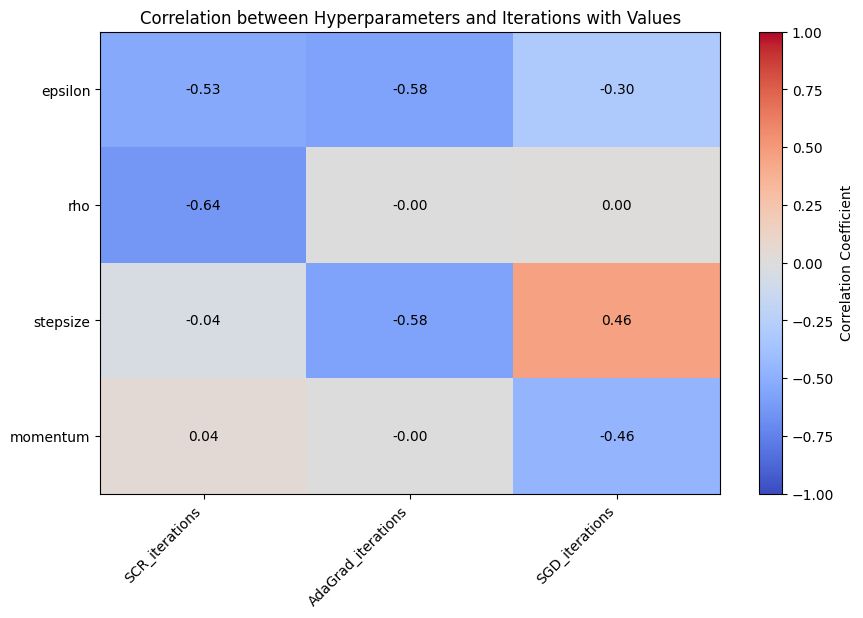

Heatmap saved to /content/drive/My Drive/correlation_heatmap.png


In [ ]:
import matplotlib.pyplot as plt

# Assuming you have mounted your Google Drive in the appropriate directory
output_path = '/content/drive/My Drive/correlation_heatmap.png'

# Extract relevant correlations for iteration variables
iteration_vars = ["SCR_iterations", "AdaGrad_iterations", "SGD_iterations"]
correlation_with_iterations = correlations.loc[["epsilon", "rho", "stepsize", "momentum"], iteration_vars]

# Plot the heatmap with numbers
plt.figure(figsize=(10, 6))
plt.imshow(correlation_with_iterations, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label="Correlation Coefficient")

# Adding the correlation values as text
for i in range(correlation_with_iterations.shape[0]):
    for j in range(correlation_with_iterations.shape[1]):
        plt.text(j, i, f"{correlation_with_iterations.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

# Formatting the plot
plt.xticks(range(len(iteration_vars)), iteration_vars, rotation=45, ha="right")
plt.yticks(range(len(correlation_with_iterations.index)), correlation_with_iterations.index)
plt.title("Correlation between Hyperparameters and Iterations with Values")

# Save the plot to Google Drive
plt.savefig(output_path, dpi=300, bbox_inches='tight')

# Display the plot in the notebook
plt.show()

print(f"Heatmap saved to {output_path}")


In [ ]:
plt.show()